In [1]:
from src import *
import matplotlib.pyplot as plt

logger = logging.getLogger("global_logger")
logging.basicConfig(filename='../gap_handler_test.log', format='%(levelname)s: %(message)s', encoding='utf-8', filemode='w', level=logging.DEBUG)
logger.info("NEW START")

replay_settings = SimulationParameters("default")
#action_names = ["kick", "sidestep", "turn", "walk", "standup_back", "standup_front"]
#indices = [0,1,2,3,4]
simulator = Simulator()
simulator.batch_size = 5
gap_handler = simulator.simulation_gap(settings=replay_settings, data=None)
gap_handler_visualizer = GapHandlerVisualizer(gap_handler)

scale_factors = gap_handler.get_scale_factors()
print(scale_factors)
gap_handler.set_scale_factors(*scale_factors)

(191.705, 769.051666666666, 54765.65656565582)


In [3]:
# define which logs to use for testing
action_name = "walk"
recording_date = "260108"
log_index = 2
joint_name = "lAnklePitch"
start_frame = 0
end_frame = -1


# extraction:   get_pos_extraction, get_vel_extraction, get_acc_extraction
# replay:       get_pos_replay, get_vel_replay, get_acc_replay
# gaps:         get_pos_gap, get_vel_gap, get_acc_gap, get_total_gap
f0 = lambda gap_object : SimulationGapData.get_pos_replay(gap_object, [joint_name], start_frame, end_frame)
f0_name = "get_pos_replay"

# get_pos_gap_avg_for_joints, get_vel_gap_avg_for_joints get_acc_gap_avg_for_joints, get_total_gap_avg_for_joints
f1 = lambda gap_object : SimulationGapData.get_total_gap_for_joints(gap_object, None, start_frame, end_frame)
f1_name = "get_total_gap_avg_for_joints"

# get_pos_gap_avg_for_frames, get_vel_gap_avg_for_frames get_acc_gap_avg_for_frames, get_total_gap_avg_for_frames
f2 = lambda gap_object : SimulationGapData.get_total_gap_for_frames(gap_object, None, start_frame, end_frame)
f2_name = "get_total_gap_avg_for_frames"

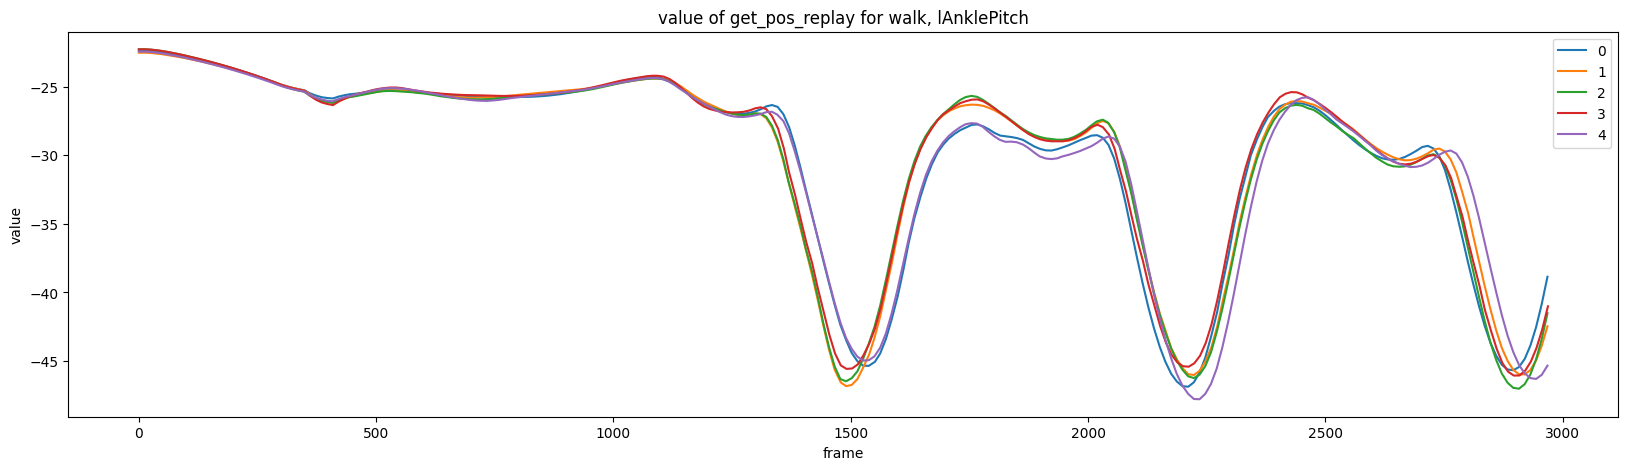

In [4]:
gap_handler_visualizer.plt_all_for_action_joint(action_name, joint_name, f0_name, f0, start_frame, end_frame)

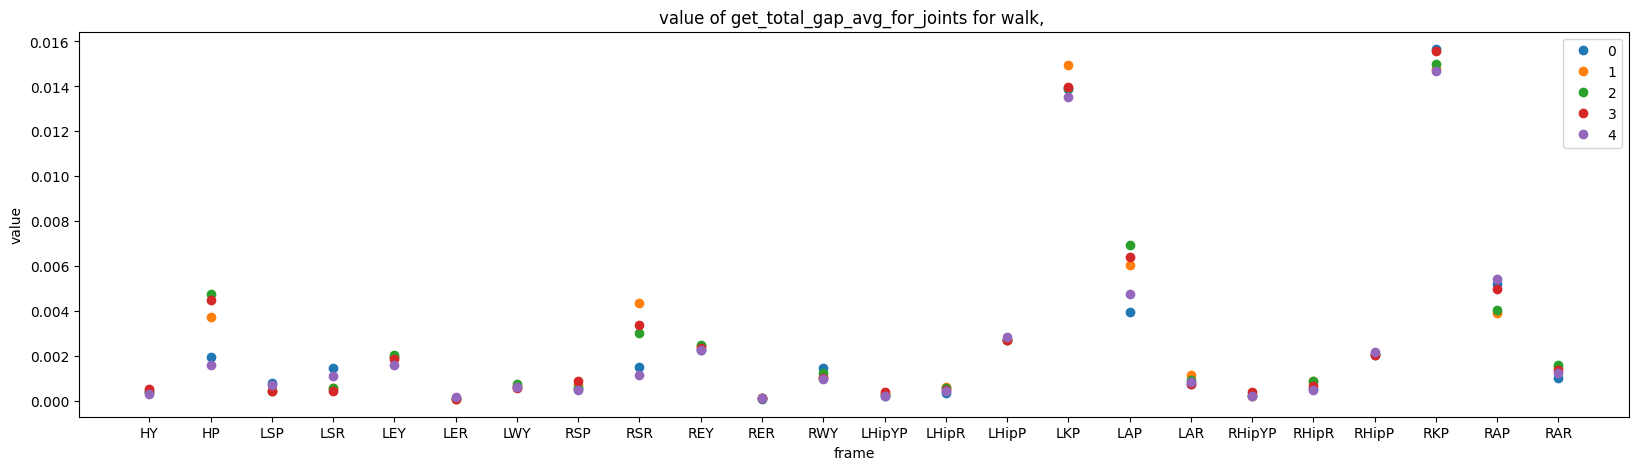

In [5]:
gap_handler_visualizer.plt_all_gap_avg_for_joints(action_name, f1_name, f1)

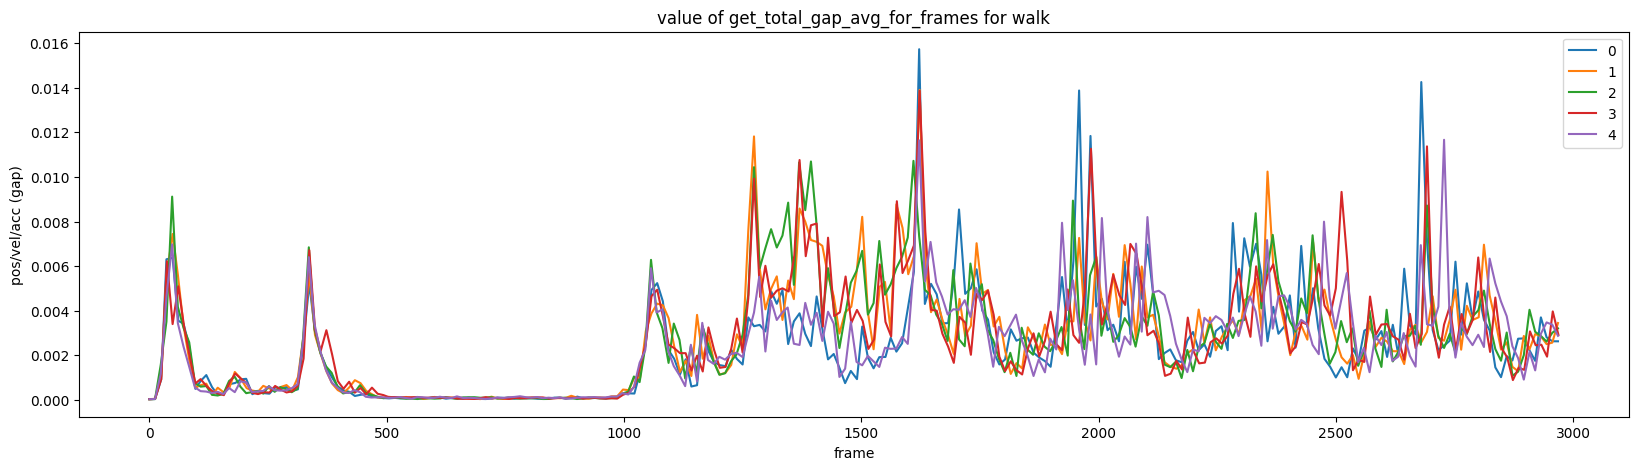

In [6]:
gap_handler_visualizer.plt_all_gap_avg_for_frames(action_name, f2_name, f2,start_frame, end_frame)

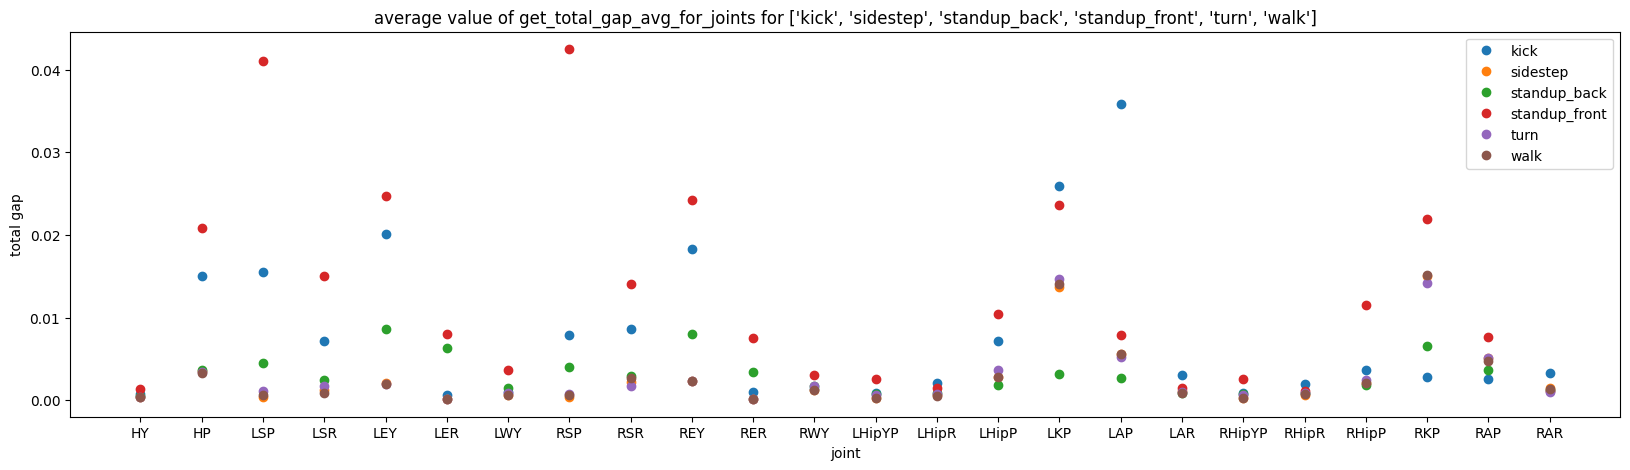

In [7]:
gap_handler_visualizer.plt_gap_avg_for_joints(f1_name, f1)

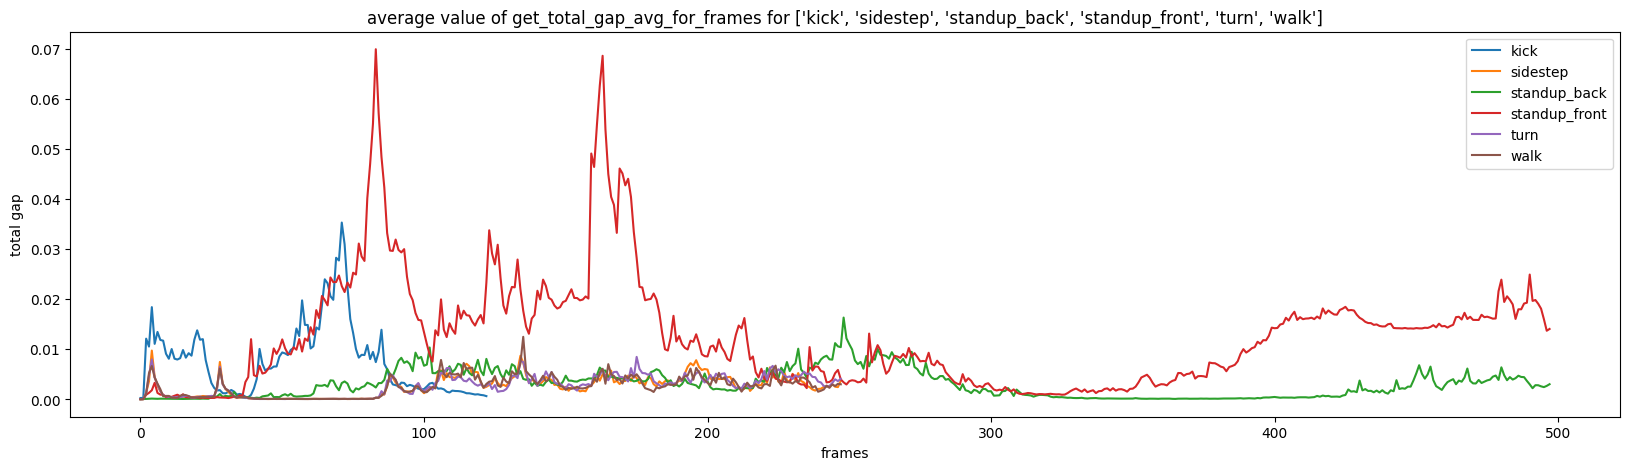

In [8]:
gap_handler_visualizer.plt_gap_avg_for_frames(f2_name, f2)

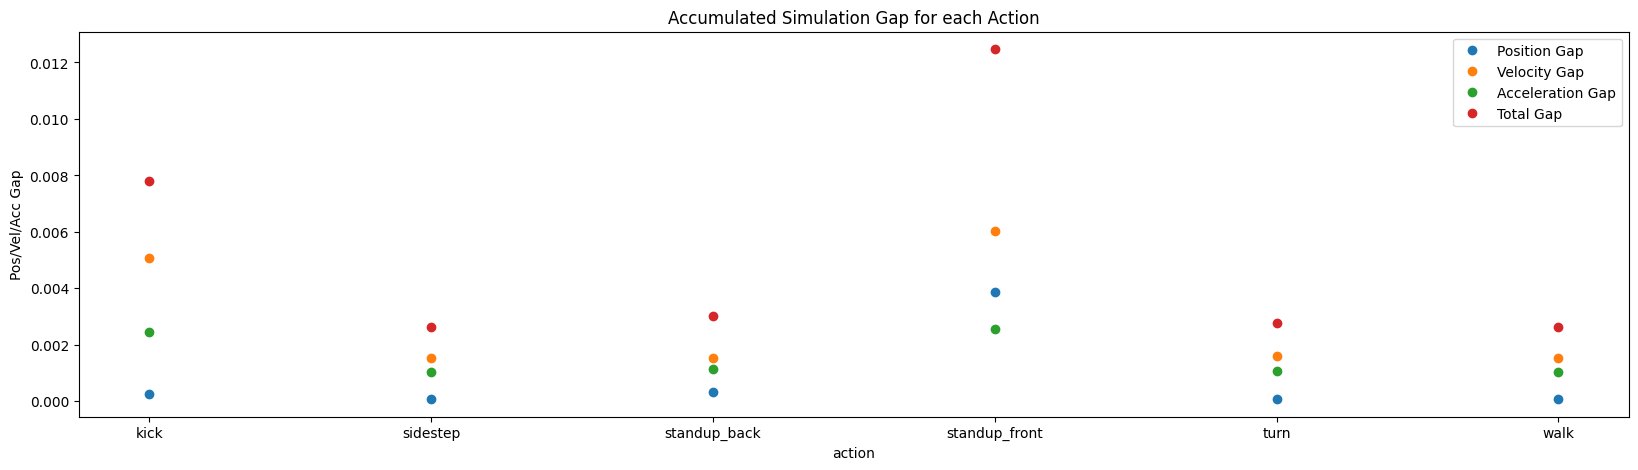

In [9]:
gap_handler_visualizer.plt_gap_avg(start_frame, end_frame)

In [10]:
print(gap_handler.get_final_FINAL_gap_avg(lambda x : SimulationGapData.get_pos_gap_avg(x, None, start_frame, end_frame)))
print(gap_handler.get_final_FINAL_gap_avg(lambda x : SimulationGapData.get_vel_gap_avg(x, None, start_frame, end_frame)))
print(gap_handler.get_final_FINAL_gap_avg(lambda x : SimulationGapData.get_acc_gap_avg(x, None, start_frame, end_frame)))
print(gap_handler.get_final_FINAL_gap_avg(lambda x : SimulationGapData.get_total_gap_avg(x, None, start_frame, end_frame)))

0.0017269898911540585
0.0036420869147017238
0.001782317517058274
0.007151394322914054


gap_handler_visualizer